# Heart Failure — Cox Proportional Hazard (Cox PH) Regression

This notebook fits the Cox Proportional Hazards model to the heart failure dataset:
- Univariate Cox regression for each feature
- Multivariate Cox regression (full model)
- Hazard ratios with confidence intervals
- Forest plot of hazard ratios
- Schoenfeld residuals — PH assumption check
- Predicted survival curves for risk profiles

**Library:** `lifelines` — `CoxPHFitter`

In [1]:
!pip install -q lifelines pandas numpy matplotlib seaborn scipy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.titlesize': 13, 'axes.labelsize': 11})
print('Libraries loaded ✔')

Libraries loaded ✔


## 1 · Load Data

In [3]:
df = pd.read_csv("/content/heart_failure_clinical_records_dataset.csv")
print(f'Loaded {len(df)} patients — shape: {df.shape}')
df.head(3)

Loaded 299 patients — shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1


## 2 · Univariate Cox Regression

In [4]:
features = ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
            'ejection_fraction', 'high_blood_pressure', 'platelets',
            'serum_creatinine', 'serum_sodium', 'sex', 'smoking']

univariate_results = []
for feat in features:
    subset = df[[feat, 'time', 'DEATH_EVENT']].copy()
    cph = CoxPHFitter()
    cph.fit(subset, duration_col='time', event_col='DEATH_EVENT')
    s = cph.summary
    univariate_results.append({
        'Feature':    feat,
        'HR':         round(s['exp(coef)'].values[0], 4),
        'CI_lower':   round(s['exp(coef) lower 95%'].values[0], 4),
        'CI_upper':   round(s['exp(coef) upper 95%'].values[0], 4),
        'p-value':    round(s['p'].values[0], 4),
        'z':          round(s['z'].values[0], 4),
    })

uni_df = pd.DataFrame(univariate_results).set_index('Feature')
uni_df['Significant'] = uni_df['p-value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else
              ('*' if p < 0.05 else 'ns')))
uni_df.sort_values('p-value')

,HR,CI_lower,CI_upper,p-value,z,Significant
Feature,,,,,,
age,1.0431,1.0257,1.0608,0.0000,4.9267,***
ejection_fraction,0.9548,0.9349,0.9752,0.0000,-4.2973,***
serum_creatinine,1.3360,1.2002,1.4872,0.0000,5.2961,***
serum_sodium,0.9346,0.8996,0.9710,0.0005,-3.4706,***
high_blood_pressure,1.5464,1.0259,2.3312,0.0374,2.0819,*
anaemia,1.4013,0.9376,2.0941,0.0998,1.6458,ns
creatinine_phosphokinase,1.0001,0.9999,1.0003,0.2625,1.1206,ns
platelets,1.0000,1.0000,1.0000,0.4659,-0.7292,ns
diabetes,0.9590,0.6388,1.4397,0.8400,-0.2019,ns


## 3 · Forest Plot — Univariate Hazard Ratios

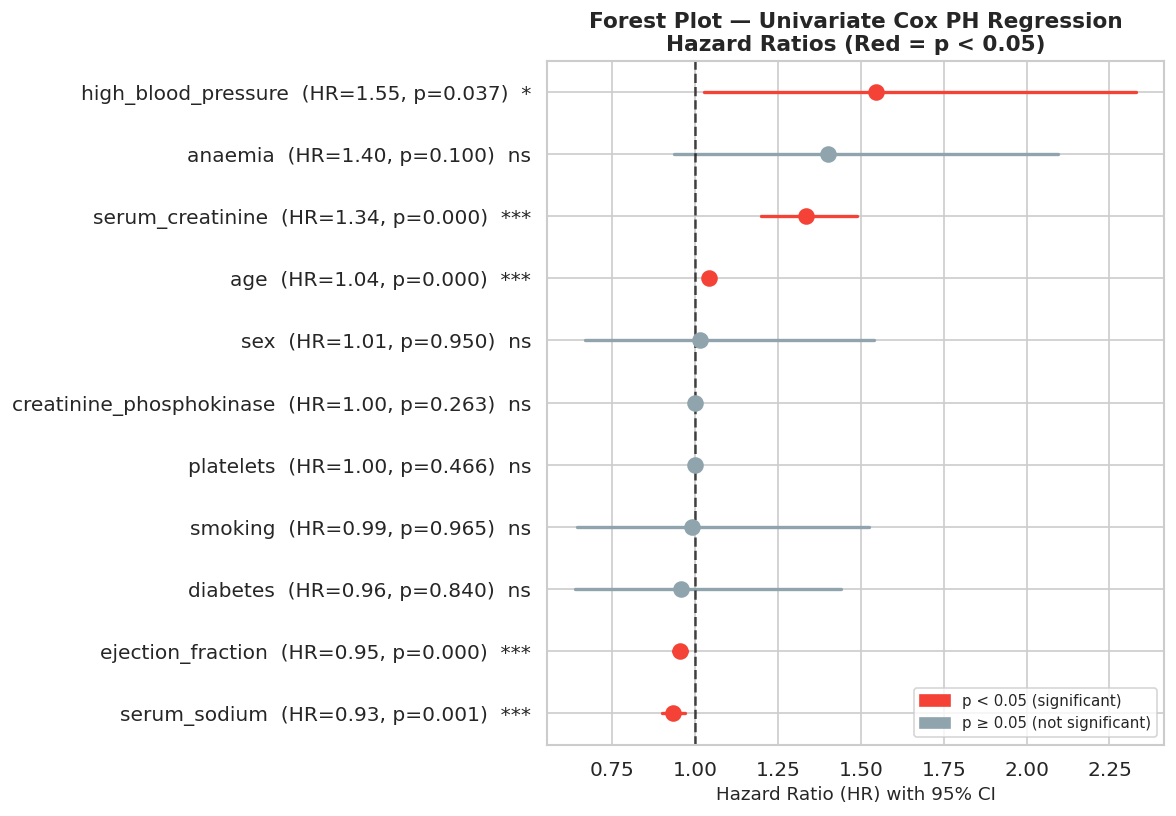

In [5]:
uni_sorted = uni_df.sort_values('HR')
n = len(uni_sorted)

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(n)

colors = ['#F44336' if p < 0.05 else '#90A4AE'
          for p in uni_sorted['p-value']]

for i, (idx, row) in enumerate(uni_sorted.iterrows()):
    ax.plot([row['CI_lower'], row['CI_upper']], [i, i],
            color=colors[i], linewidth=2, solid_capstyle='round')
    ax.scatter(row['HR'], i, color=colors[i], s=80, zorder=5)

ax.axvline(1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_yticks(range(n))
ax.set_yticklabels([f"{idx}  (HR={row.HR:.2f}, p={row['p-value']:.3f})  {row.Significant}"
                    for idx, row in uni_sorted.iterrows()])
ax.set_xlabel('Hazard Ratio (HR) with 95% CI')
ax.set_title('Forest Plot — Univariate Cox PH Regression\nHazard Ratios (Red = p < 0.05)',
             fontweight='bold')

red_patch  = mpatches.Patch(color='#F44336', label='p < 0.05 (significant)')
grey_patch = mpatches.Patch(color='#90A4AE', label='p ≥ 0.05 (not significant)')
ax.legend(handles=[red_patch, grey_patch], fontsize=9)

plt.tight_layout()
plt.show()

## 4 · Multivariate Cox PH Model — Full Model

In [7]:
cox_df = df[features + ['time', 'DEATH_EVENT']].copy()

cph_full = CoxPHFitter(penalizer=0.0)
cph_full.fit(cox_df, duration_col='time', event_col='DEATH_EVENT')

print('═' * 70)
print(' MULTIVARIATE COX PH MODEL SUMMARY')
print('═' * 70)
cph_full.print_summary(model='untransformed', decimals=4)

print(f'\nConcordance Index (C-index): {cph_full.concordance_index_:.4f}')
print(f'Log-likelihood             : {cph_full.log_likelihood_:.4f}')
print(f'AIC                        : {cph_full.AIC_partial_:.4f}')

══════════════════════════════════════════════════════════════════════
 MULTIVARIATE COX PH MODEL SUMMARY
══════════════════════════════════════════════════════════════════════


<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -468.2279
         time fit was run = 2026-03-28 17:53:32 UTC
                    model = untransformed

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
age                       0.0464    1.0475    0.0093          0.0281          0.0647              1.0285              1.0668
anaemia                   0.4601    1.5843    0.2168          0.0351          0.8851              1.0358              2.4233
creatinine_phosphokinase  0.0002    1.0002    0.0001          0.0000          0.0004              1.0000              1.0004
diabetes                  0.1399    1.1501    0.2231         -0.2975          0.5772              0.7427              1.7811
ejection_fraction        -0.0489    0.9522    0.0105         -0.0695         -0.0284              0.9329              0.9720
high_blood_pressure       0.4757    1.6092    0.2162          0.0520          0.8995              1.0534              2.4583
platelets                -0.0000    1.0000    0.0000         -0.0000          0.0000              1.0000              1.0000
serum_creatinine          0.3210    1.3786    0.0702          0.1835          0.4586              1.2014              1.5818
serum_sodium             -0.0442    0.9568    0.0233         -0.0898          0.0014              0.9141              1.0014
sex                      -0.2375    0.7886    0.2516         -0.7307          0.2556              0.4816              1.2913
smoking                   0.1289    1.1376    0.2512         -0.3635          0.6213              0.6953              1.8614

                          cmp to       z      p  -log2(p)
covariate                                                
age                       0.0000  4.9773 <5e-05   20.5645
anaemia                   0.0000  2.1220 0.0338    4.8854
creatinine_phosphokinase  0.0000  2.2255 0.0260    5.2627
diabetes                  0.0000  0.6269 0.5307    0.9139
ejection_fraction         0.0000 -4.6719 <5e-05   18.3540
high_blood_pressure       0.0000  2.2005 0.0278    5.1704
platelets                 0.0000 -0.4116 0.6806    0.5550
serum_creatinine          0.0000  4.5751 <5e-05   17.6806
serum_sodium              0.0000 -1.8993 0.0575    4.1195
sex                       0.0000 -0.9440 0.3452    1.5346
smoking                   0.0000  0.5132 0.6078    0.7183
---
Concordance = 0.7408
Partial AIC = 958.4557
log-likelihood ratio test = 81.9545 on 11 df
-log2(p) of ll-ratio test = 40.5590


Concordance Index (C-index): 0.7408
Log-likelihood             : -468.2279
AIC                        : 958.4557


## 5 · Forest Plot — Multivariate Hazard Ratios

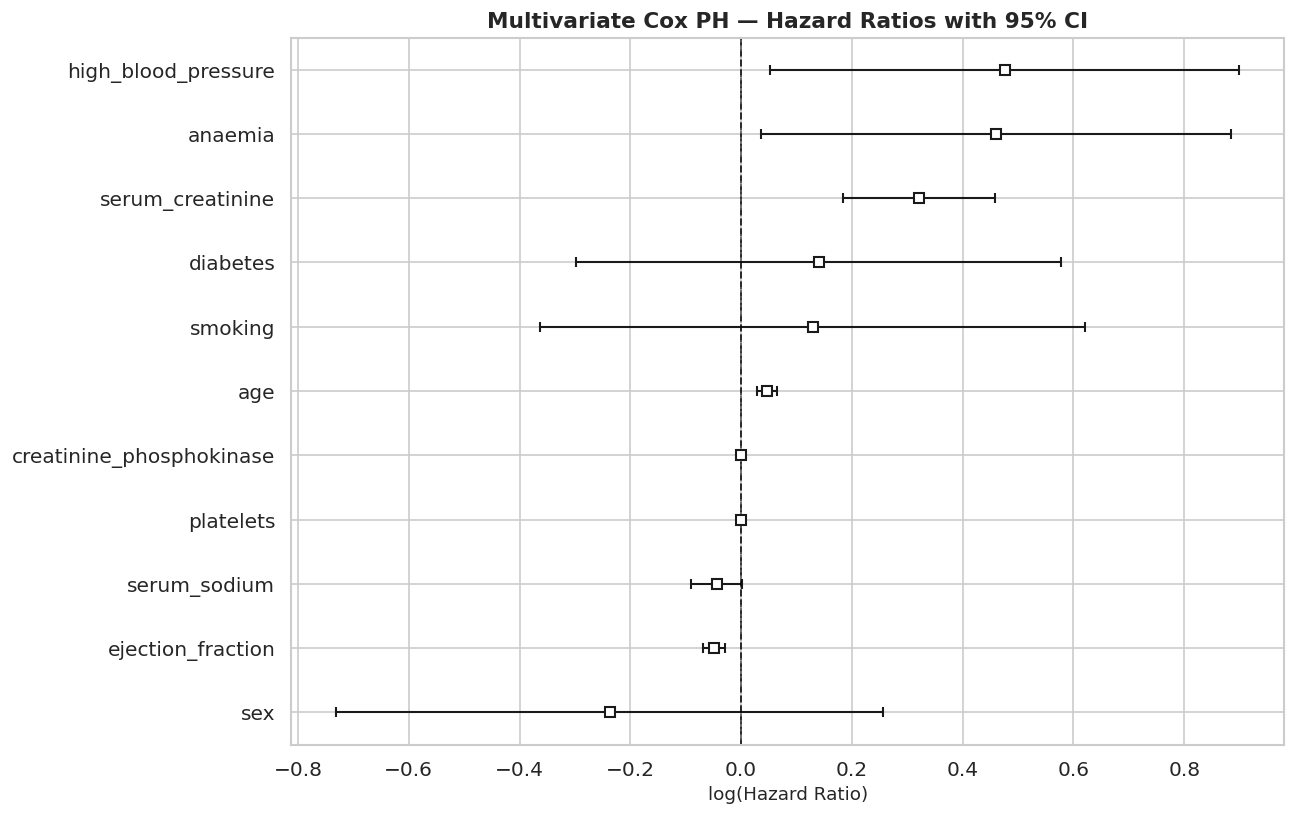

In [8]:
fig, ax = plt.subplots(figsize=(11, 7))
cph_full.plot(ax=ax)
ax.set_title('Multivariate Cox PH — Hazard Ratios with 95% CI',
             fontweight='bold')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
ax.set_xlabel('log(Hazard Ratio)')
plt.tight_layout()
plt.show()

## 6 · Reduced Model — Significant Covariates Only

In [9]:
# Features with p < 0.05 in multivariate model
sig_feats = cph_full.summary[cph_full.summary['p'] < 0.05].index.tolist()
print('Significant features (p < 0.05):', sig_feats)

cox_reduced_df = df[sig_feats + ['time', 'DEATH_EVENT']].copy()

cph_reduced = CoxPHFitter()
cph_reduced.fit(cox_reduced_df, duration_col='time', event_col='DEATH_EVENT')

print('\n── Reduced Model Summary ──')
cph_reduced.print_summary(decimals=4)

print(f'\nFull model   C-index: {cph_full.concordance_index_:.4f}')
print(f'Reduced model C-index: {cph_reduced.concordance_index_:.4f}')

Significant features (p < 0.05): ['age', 'anaemia', 'creatinine_phosphokinase', 'ejection_fraction', 'high_blood_pressure', 'serum_creatinine']

── Reduced Model Summary ──


<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -470.6964
         time fit was run = 2026-03-28 17:53:40 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
age                       0.0436    1.0446    0.0089          0.0263          0.0610              1.0266              1.0629
anaemia                   0.3933    1.4818    0.2129         -0.0241          0.8106              0.9762              2.2493
creatinine_phosphokinase  0.0002    1.0002    0.0001          0.0000          0.0004              1.0000              1.0004
ejection_fraction        -0.0518    0.9495    0.0101         -0.0715         -0.0321              0.9310              0.9684
high_blood_pressure       0.4668    1.5948    0.2129          0.0494          0.8841              1.0506              2.4209
serum_creatinine          0.3483    1.4167    0.0655          0.2200          0.4767              1.2460              1.6108

                          cmp to       z      p  -log2(p)
covariate                                                
age                       0.0000  4.9256 <5e-05   20.1816
anaemia                   0.0000  1.8468 0.0648    3.9485
creatinine_phosphokinase  0.0000  1.9933 0.0462    4.4351
ejection_fraction         0.0000 -5.1523 <5e-05   21.8904
high_blood_pressure       0.0000  2.1918 0.0284    5.1384
serum_creatinine          0.0000  5.3186 <5e-05   23.1888
---
Concordance = 0.7377
Partial AIC = 953.3927
log-likelihood ratio test = 77.0175 on 6 df
-log2(p) of ll-ratio test = 45.9473


Full model   C-index: 0.7408
Reduced model C-index: 0.7377


## 7 · Proportional Hazards Assumption Check

In [10]:
# Schoenfeld residuals test
results_ph = proportional_hazard_test(cph_full, cox_df, time_transform='rank')
print('── Schoenfeld Residuals — PH Assumption Test ──')
print('(p < 0.05 suggests violation of PH assumption)\n')
results_ph.print_summary(decimals=4)

── Schoenfeld Residuals — PH Assumption Test ──
(p < 0.05 suggests violation of PH assumption)




   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'ejection_fraction' failed the non-proportional test: p-value is 0.0127.

   Advice 1: the functional form of the variable 'ejection_fraction' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'ejection_fraction' using pd.cut, and then specify it in
`strata=['ejection_fraction', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment

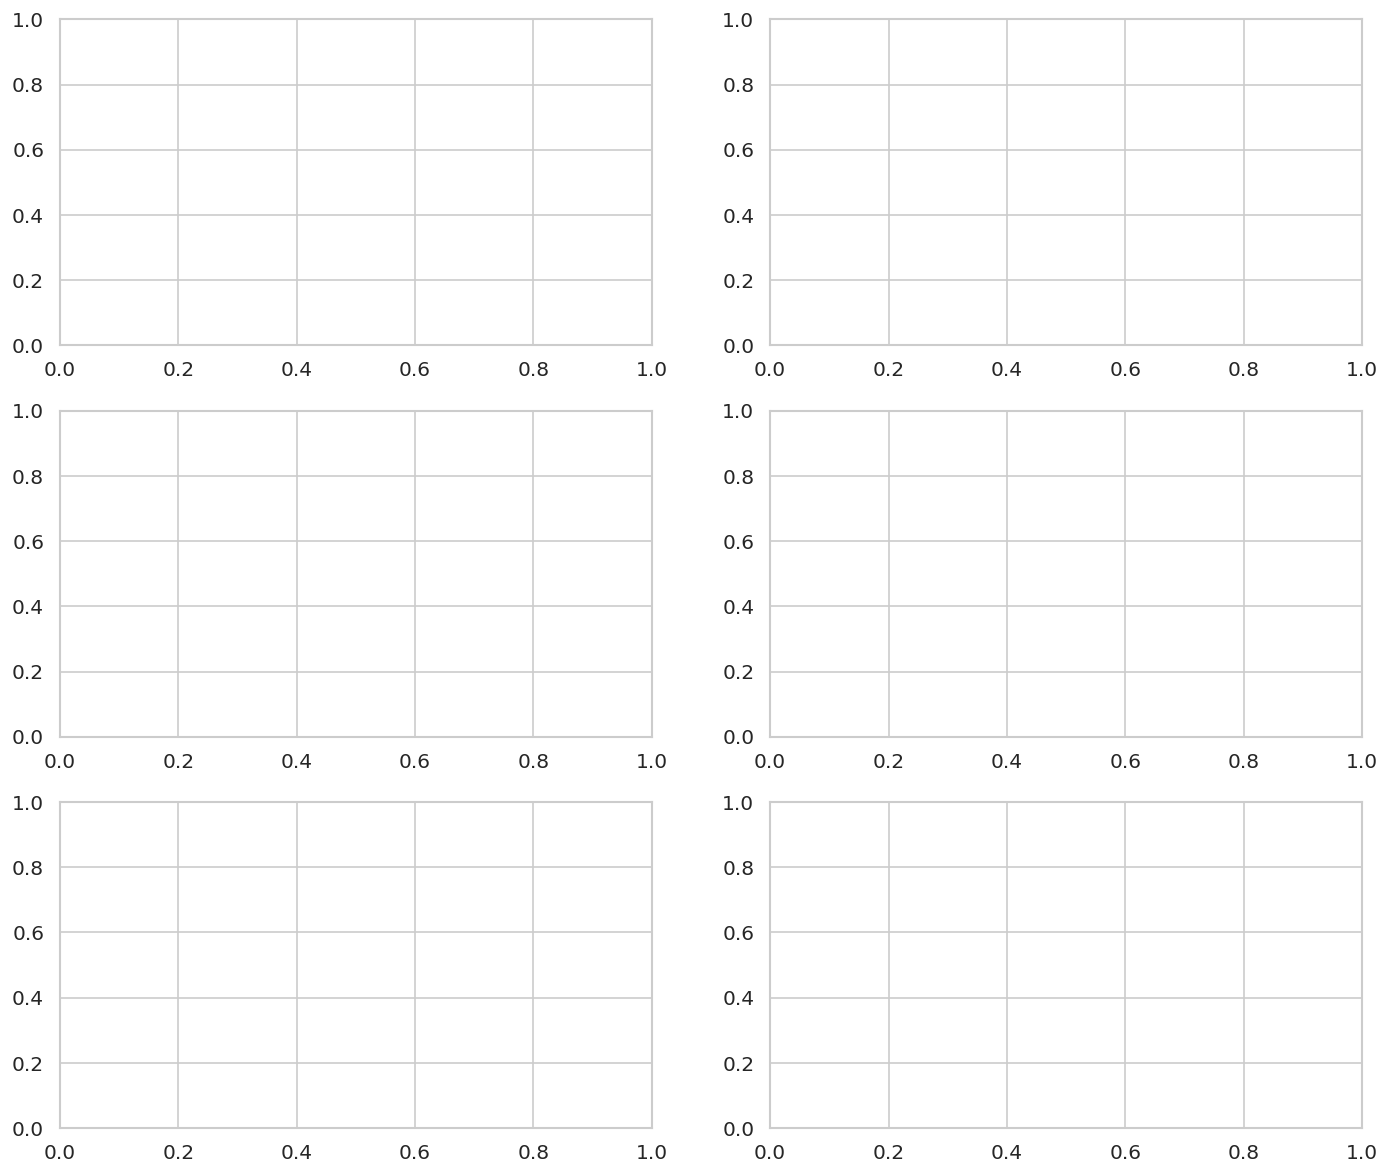

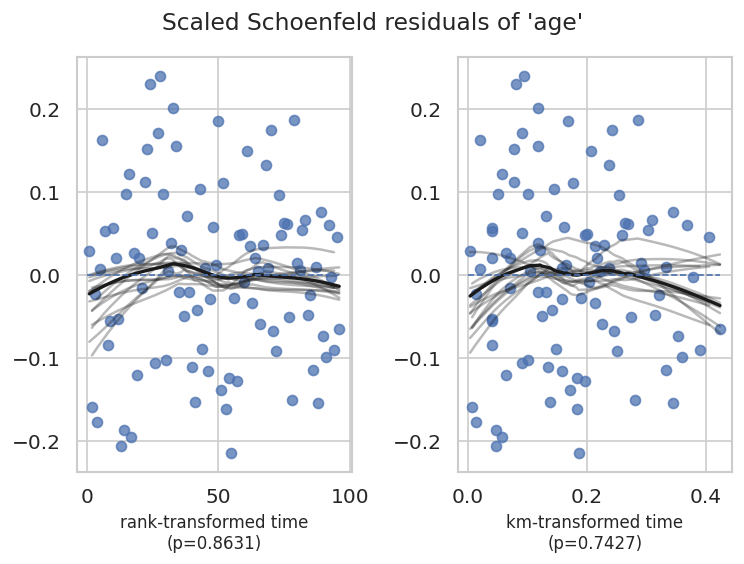

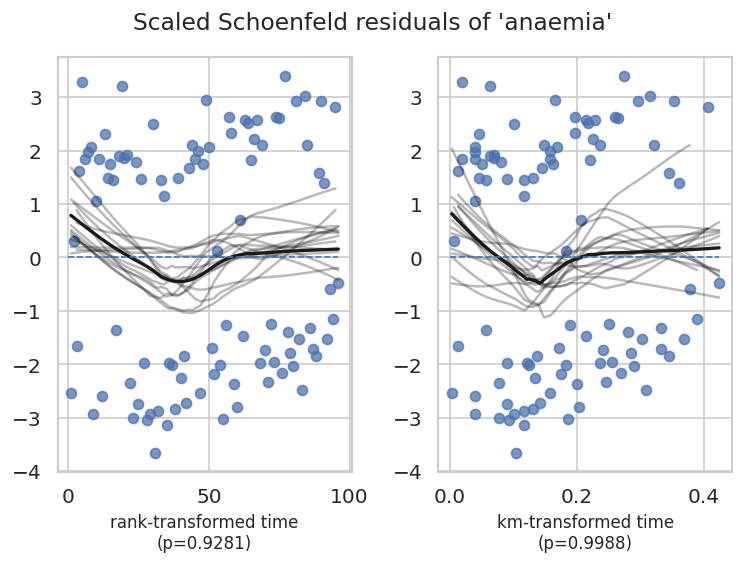

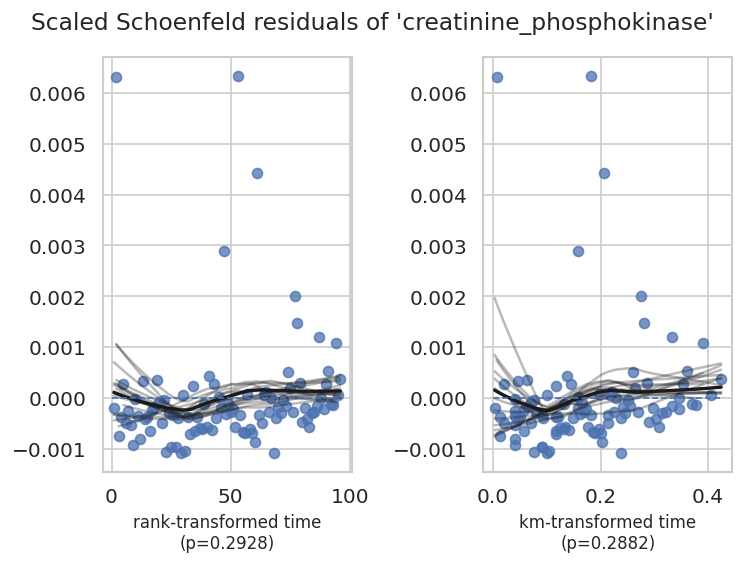

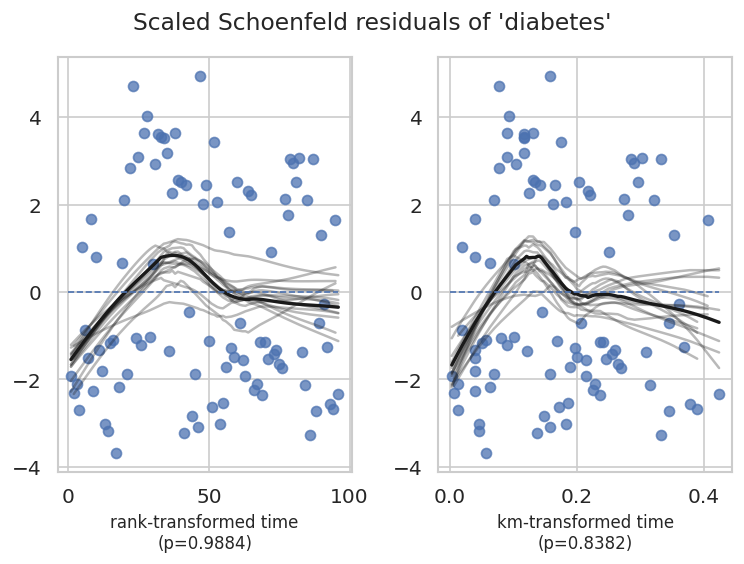

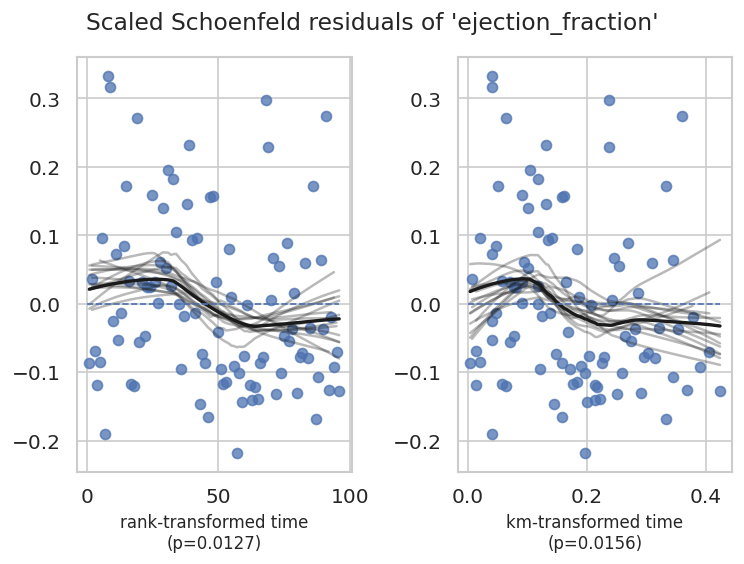

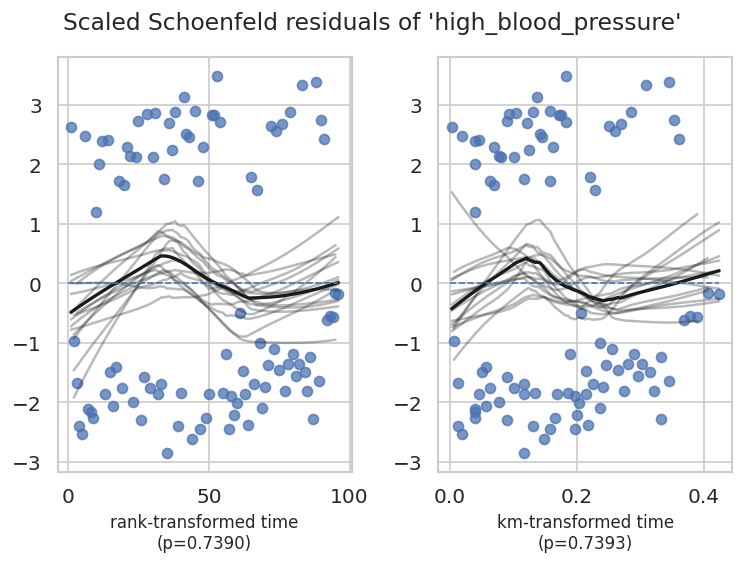

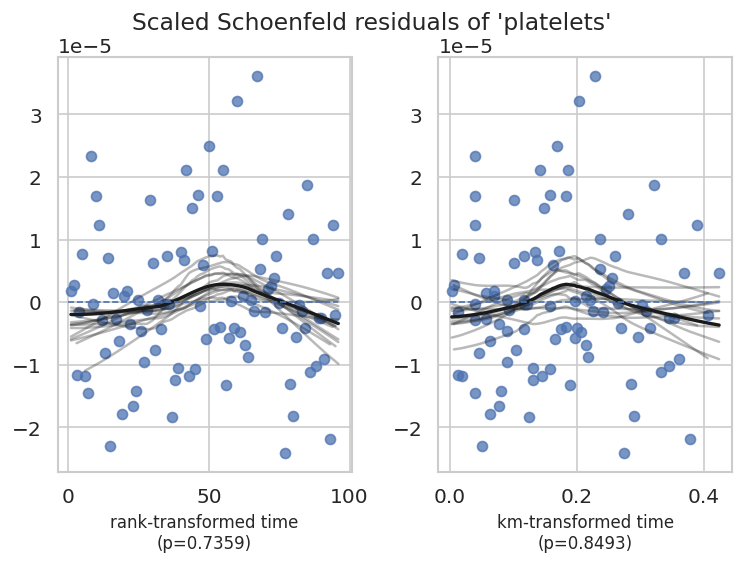

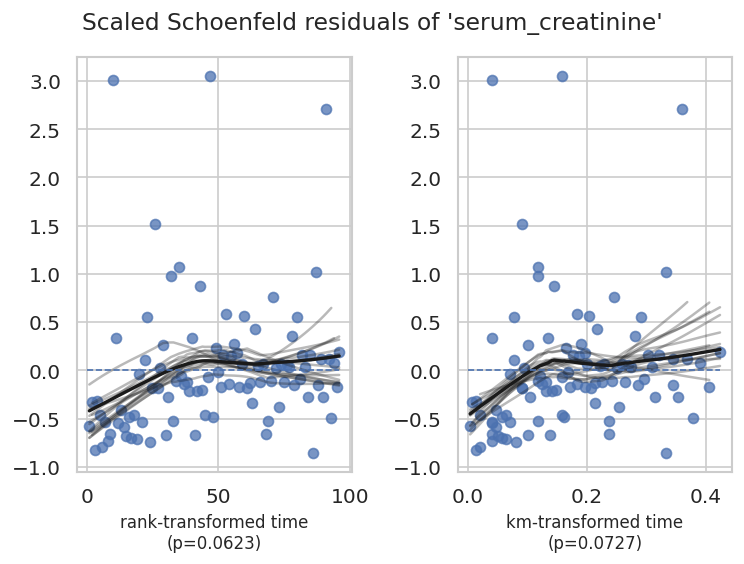

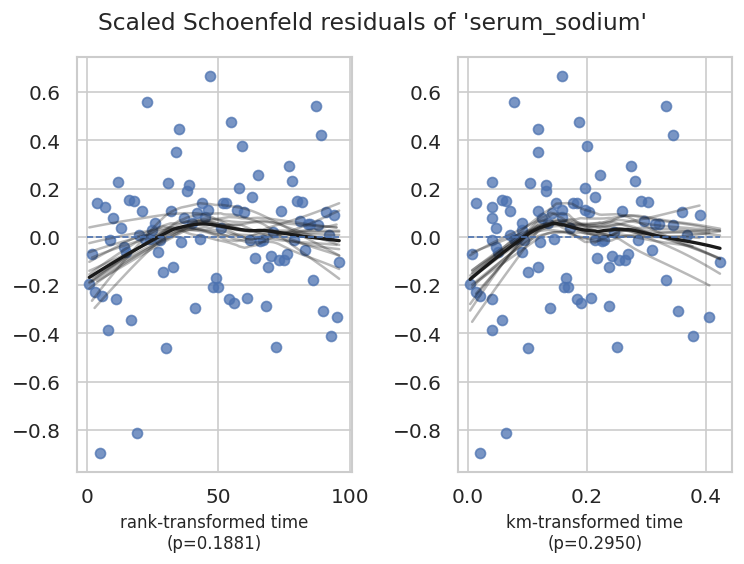

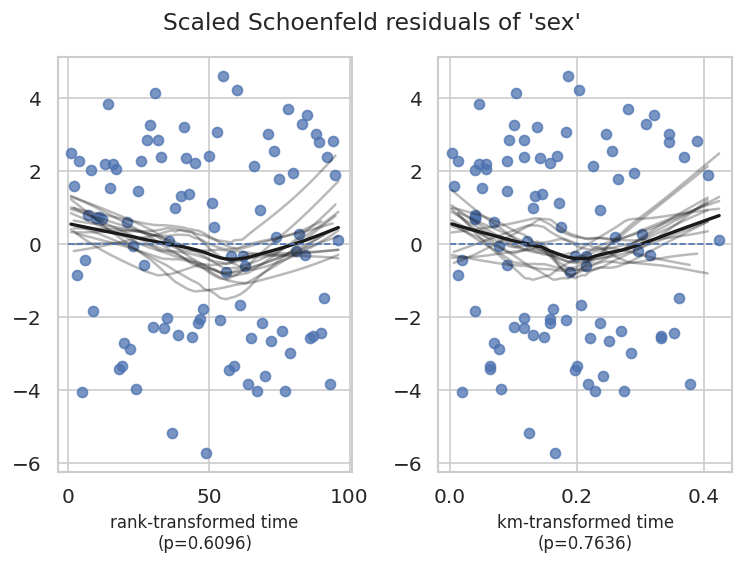

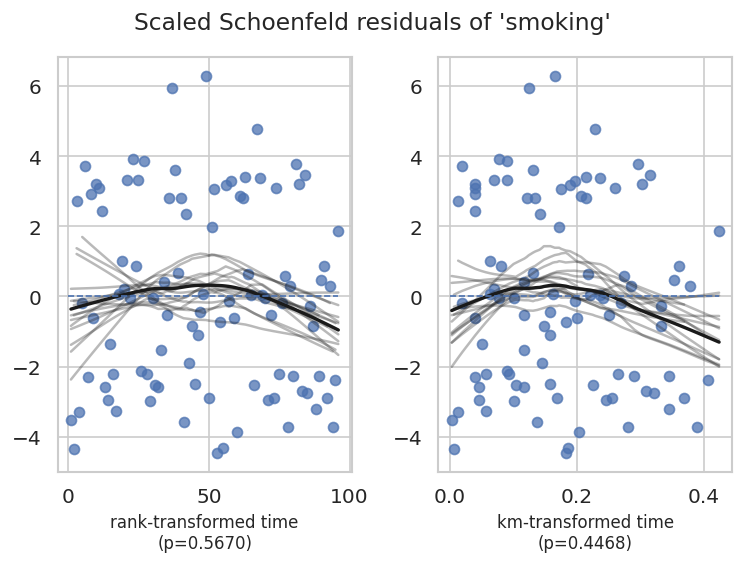

In [11]:
# Visual: Schoenfeld residuals plot for significant features
n_feats = min(len(sig_feats), 6)
cols_plot = sig_feats[:n_feats]
n_cols = 2
n_rows = (n_feats + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten() if n_feats > 1 else [axes]

cph_full.check_assumptions(cox_df, p_value_threshold=0.05, show_plots=True)
plt.show()

## 8 · Predicted Survival Curves for Risk Profiles

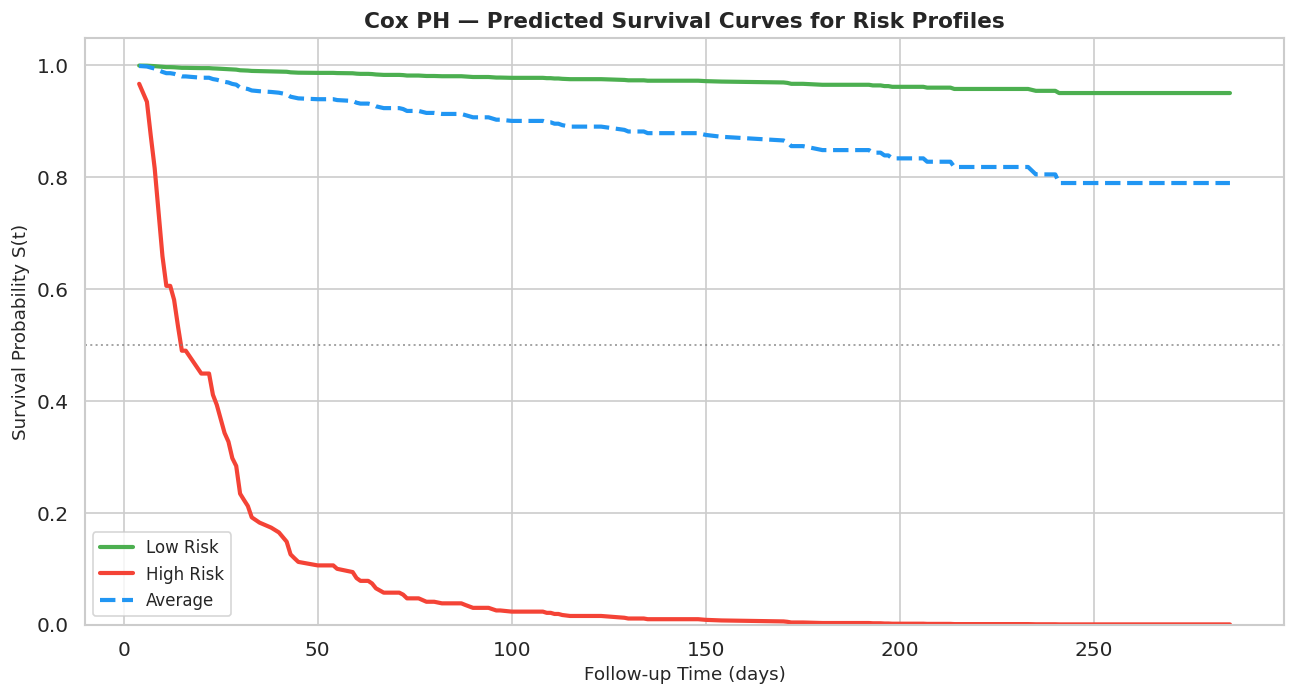

In [12]:
# Define representative patient profiles
profiles = pd.DataFrame([
    # Low-risk profile
    {'label': 'Low Risk',
     'age': 45, 'anaemia': 0, 'creatinine_phosphokinase': 150,
     'diabetes': 0, 'ejection_fraction': 50, 'high_blood_pressure': 0,
     'platelets': 250000, 'serum_creatinine': 1.0,
     'serum_sodium': 140, 'sex': 1, 'smoking': 0},
    # High-risk profile
    {'label': 'High Risk',
     'age': 75, 'anaemia': 1, 'creatinine_phosphokinase': 600,
     'diabetes': 1, 'ejection_fraction': 25, 'high_blood_pressure': 1,
     'platelets': 150000, 'serum_creatinine': 2.5,
     'serum_sodium': 130, 'sex': 0, 'smoking': 1},
    # Average profile
    {'label': 'Average',
     'age': 60, 'anaemia': 0, 'creatinine_phosphokinase': 300,
     'diabetes': 0, 'ejection_fraction': 38, 'high_blood_pressure': 0,
     'platelets': 260000, 'serum_creatinine': 1.3,
     'serum_sodium': 137, 'sex': 1, 'smoking': 0},
])

labels = profiles['label'].tolist()
profiles_data = profiles.drop(columns='label')

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#4CAF50', '#F44336', '#2196F3']
linestyles = ['-', '-', '--']

for i, (_, row) in enumerate(profiles_data.iterrows()):
    sf = cph_full.predict_survival_function(row.to_frame().T)
    ax.plot(sf.index, sf.values.flatten(),
            color=colors[i], linewidth=2.5,
            linestyle=linestyles[i], label=labels[i])

ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
ax.set_xlabel('Follow-up Time (days)')
ax.set_ylabel('Survival Probability S(t)')
ax.set_title('Cox PH — Predicted Survival Curves for Risk Profiles',
             fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 9 · Predicted Partial Hazard for All Patients

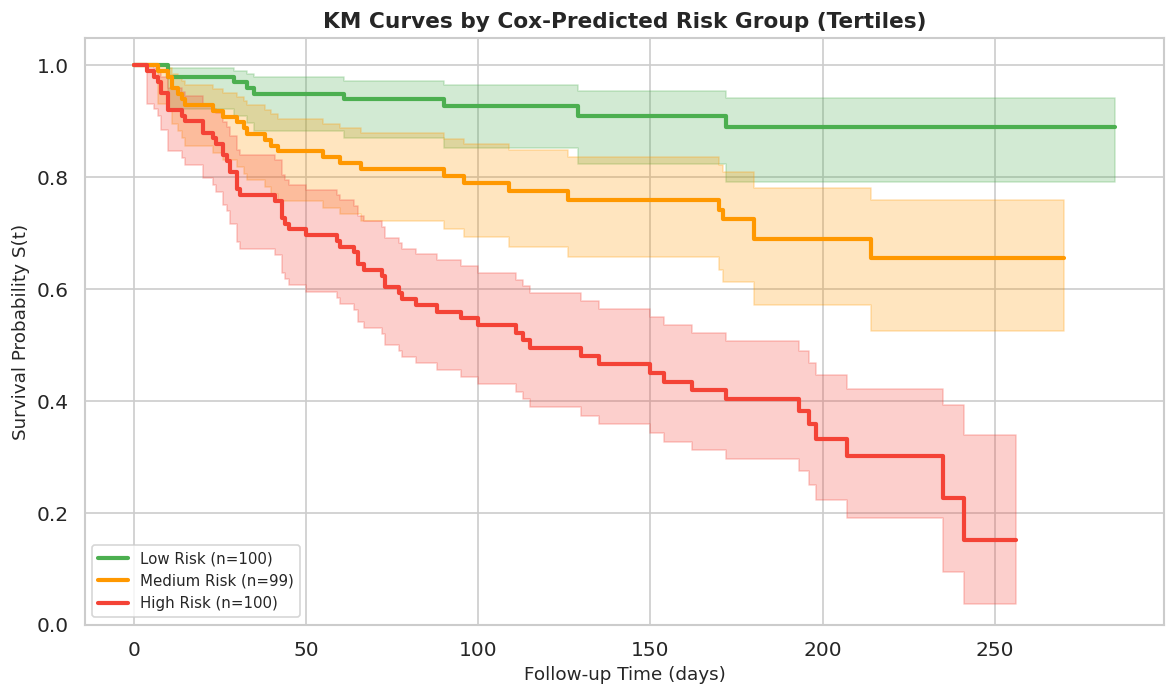

Mortality rate per risk group:
             Deaths    N  mortality_rate
risk_group                              
Low Risk          9  100             9.0
Medium Risk      27   99            27.3
High Risk        60  100            60.0


In [13]:
df['partial_hazard'] = cph_full.predict_partial_hazard(cox_df)
df['risk_group'] = pd.qcut(df['partial_hazard'], q=3,
                            labels=['Low Risk', 'Medium Risk', 'High Risk'])

fig, ax = plt.subplots(figsize=(10, 6))
palette = {'Low Risk': '#4CAF50', 'Medium Risk': '#FF9800', 'High Risk': '#F44336'}

for group, color in palette.items():
    mask = df['risk_group'] == group
    kmf = KaplanMeierFitter()
    kmf.fit(df.loc[mask, 'time'], df.loc[mask, 'DEATH_EVENT'],
            label=f'{group} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax, color=color, linewidth=2.5)

ax.set_xlabel('Follow-up Time (days)')
ax.set_ylabel('Survival Probability S(t)')
ax.set_title('KM Curves by Cox-Predicted Risk Group (Tertiles)',
             fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Mortality rate per group
print('Mortality rate per risk group:')
print(df.groupby('risk_group', observed=True)['DEATH_EVENT']
        .agg(['sum', 'count'])
        .assign(mortality_rate=lambda x: (x['sum']/x['count']*100).round(1))
        .rename(columns={'sum': 'Deaths', 'count': 'N'}))

## 10 · Interpretation Summary

In [14]:
print('=' * 65)
print('  COX PH REGRESSION — KEY FINDINGS')
print('=' * 65)
summary = cph_full.summary[['exp(coef)', 'exp(coef) lower 95%',
                             'exp(coef) upper 95%', 'p']].copy()
summary.columns = ['HR', 'HR_lower', 'HR_upper', 'p_value']
summary['sig'] = summary['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else
              ('*' if p < 0.05 else 'ns')))
summary_sorted = summary.sort_values('p_value')
print(summary_sorted.round(4).to_string())
print(f'\nC-index (discrimination): {cph_full.concordance_index_:.4f}')
print('\nInterpretation guidance:')
print('  HR > 1 → Higher hazard / worse survival')
print('  HR < 1 → Lower hazard  / better survival')
print('  HR = 1 → No effect')

  COX PH REGRESSION — KEY FINDINGS
                              HR  HR_lower  HR_upper  p_value  sig
covariate                                                         
age                       1.0475    1.0285    1.0668   0.0000  ***
ejection_fraction         0.9522    0.9329    0.9720   0.0000  ***
serum_creatinine          1.3786    1.2014    1.5818   0.0000  ***
creatinine_phosphokinase  1.0002    1.0000    1.0004   0.0260    *
high_blood_pressure       1.6092    1.0534    2.4583   0.0278    *
anaemia                   1.5843    1.0358    2.4233   0.0338    *
serum_sodium              0.9568    0.9141    1.0014   0.0575   ns
sex                       0.7886    0.4816    1.2913   0.3452   ns
diabetes                  1.1501    0.7427    1.7811   0.5307   ns
smoking                   1.1376    0.6953    1.8614   0.6078   ns
platelets                 1.0000    1.0000    1.0000   0.6806   ns

C-index (discrimination): 0.7408

Interpretation guidance:
  HR > 1 → Higher hazard / worse s